In [28]:
import collections
from IPython import display
import matplotlib.pyplot as plt

import numpy as np
from scipy.linalg import svdvals
import torch
import itertools as itr
from torch import nn
from common.ffn.ffn_relu import ParametricReLUNet
from common.coeff_calc.coeff_calc_ntk import NTKSimulator
from common.ffn_model.minst.ffn_minst_util import MetaData, NTKCalculator, StepCalculatorEtaNtk
from common.ffn_model.minst.ffn_minst_relu import MNISTReLU

from torch.utils.data import DataLoader
from torchvision.datasets import EMNIST
from torchvision.transforms import ToTensor
from common.util import *
import logging

In [29]:
logging.basicConfig(filename="log_ntk_eminst.log",
                level=logging.WARN,
                format='%(levelname)s: %(asctime)s %(message)s',
                datefmt='%m/%d/%Y %I:%M:%S')

In [30]:
# use it to conver from PIL to torch.Tensor
image_transform = ToTensor()

train_dataset = EMNIST(root='./', split='letters', train=True, download=True, transform=image_transform)
test_dataset = EMNIST(root='./', split='letters', train=False, download=True, transform=image_transform)

In [31]:
BATCH_SIZE = 64

train_dataloader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

test_dataloader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE
)

In [32]:
INPUT_DIM = 28 * 28
OUTPUT_DIM = 26  # num classes

lb, lw, ln = 1e-2, 7.5, 3 #1e-2, 1e-1, 3 #1e-2,1,1 #1e-2, 1e-2, 1
#Weights distribution variances are set as in (5.67)
slope_plus, slope_minus=1.0, 0.0
cb, cw = 0, 2.0/(slope_plus**2.0 + slope_minus**2.0)
meta = MetaData(input_dim = INPUT_DIM, input_width = 250, hidden_width = 100, output_dim = OUTPUT_DIM\
                , batch_size = BATCH_SIZE, lb = lb, lw = lw)

DEVICE = torch.device('cpu')  # change to `cuda:0` when available
testNet = MNISTReLU(meta) #INPUT_DIM, OUTPUT_DIM)
testNet.set_log_level("info")
testNet.set_slopes(slope_plus, slope_minus)
testNet.init_weights(cb, cw)
testNet.to(DEVICE)


FeedForwardNet created with n0=784, nk=0, nl=26, l=0, bias_on=True


MNISTReLU(
  (input_fc): Linear(in_features=784, out_features=250, bias=True)
  (hidden_fc): Linear(in_features=250, out_features=100, bias=True)
  (output_fc): Linear(in_features=100, out_features=26, bias=True)
)

#### NTK by formulas (10.44) and (10.45)

In [33]:
images, labels_raw = next(iter(train_dataloader))
labels = torch.tensor([x-1 for x in labels_raw])
images = images.to(DEVICE)
labels = labels.to(DEVICE)
#images = [batch_size, height, width]
batch_size = images.shape[0]
xx = images.view(batch_size, -1)

def PReLUz(input: float) -> float:
    return slope_plus * input if input >= 0 else slope_minus * input

def PReLUdrv(input: float) -> float:
    return slope_plus if input >= 0 else slope_minus

act = np.vectorize(PReLUz)
drv = np.vectorize(PReLUdrv)

KK = np.zeros((ln, BATCH_SIZE, BATCH_SIZE))
Theta = np.zeros_like(KK)
sim = NTKSimulator(cb=cb, cw=cw, lb=lb, lw=lw, act=act, drv=drv, n_samples=2_000_000)
sim.calculate_layer0(KK, Theta, np.transpose(xx.detach().numpy()))
for idx in range(1, ln):
    sim.calculate_layer(KK, Theta, idx)
    print('-', end='')

thetaL = Theta[-1]

--

In [34]:
def rf(value):
    return f"{value:.5f}"

def flatten2d(HL):  #HL - [output_dim, output_dim, batch_size, batch_size]
    tmp = np.moveaxis(HL, 1, 2)
    dim = tmp.shape
    return np.reshape(tmp, (dim[0]*dim[1], dim[2]*dim[3]))

def calc_averages(HL, meta):
    HL_avg = np.zeros((meta.batch_size, meta.batch_size))
    HL_var, HLNDG_avg, HLNDG_var = np.zeros_like(HL_avg), np.zeros_like(HL_avg), np.zeros_like(HL_avg)

    for alpha1, alpha2 in itr.product(range(meta.batch_size), range(meta.batch_size)):
        data = [HL[num, num, alpha1, alpha2] for num in np.arange(meta.output_dim)]
        HL_avg[alpha1, alpha2] = np.average(data)
        HL_var[alpha1, alpha2] = np.var(data, ddof=1)
        data2 = [HL[num1, num2, alpha1, alpha2] \
                 for num1, num2 in itr.product(range(meta.output_dim), range(meta.output_dim)) if num1 != num2]
        HLNDG_avg[alpha1, alpha2] = np.average(data2)
        HLNDG_var[alpha1, alpha2] = np.var(data2, ddof=1)

    return HL_avg, HL_var, HLNDG_avg, HLNDG_var


def visualise(history_params):
    # visualize all together
    display.clear_output()
    fig, axes = plt.subplots(2, 2, figsize=(20, 14))
    axes[0, 0].set_title('Loss (cross-entropy)')
    axes[0, 0].plot(history_params['train_loss'], label='Train Loss')
    axes[0, 0].plot(history_params['test_loss'], label='Test Loss')
    axes[0, 0].grid()
    axes[0, 0].legend(fontsize=20)
    
    axes[0, 1].set_title('Accuracy')
    axes[0, 1].plot(history_params['train_accuracy'], label='Train Accuracy')
    axes[0, 1].plot(history_params['test_accuracy'], label='Test Accuracy')
    axes[0, 1].grid()
    axes[0, 1].legend(fontsize=20)

    axes[1, 0].set_title('Train-step eta')
    axes[1, 0].plot(history_params['train_eta'])
    axes[1, 0].grid()
    #ax2.legend(fontsize=20)

    axes[1, 1].set_title('Singular values for flattened NTK')
    axes[1, 1].plot(history_params['ntk_sungular_min'], label='Singular min value')
    axes[1, 1].plot(history_params['ntk_sungular_max'], label='Singular max value')
    axes[1, 1].grid()
    axes[1, 1].legend(fontsize=20)
    
    plt.show()


#### NTK by formulas (8.4)

In [35]:
logits = testNet.forward_(xx)
calc0 = NTKCalculator(meta)
calc0.calculate_derivatives(testNet, logits)
HL = calc0.calculate_NTK()

print("Calculating averages and variances")
HL_avg, HL_var, HLNDG_avg, HLNDG_var = calc_averages(HL, meta)


Calculating averages and variances


In [36]:
print("For NTK calculated by (8.4) and averaged for i_1=i_2:\n max(abs)={}, avg(abs)={}".\
      format(np.max(np.abs(HL_avg)), np.average(np.abs(HL_avg))))
print("For delta between NTK calculated by (8.4)/averaged for i_1=i_2 and NTK calculated by (10.44)-(10.45):\n max(abs(Δ))={}, avg(abs(Δ))={}".\
      format(np.max(np.abs(HL_avg - thetaL)), np.average(np.abs(HL_avg - thetaL))))
print("For NTK calculated by (8.4) for non-diagonal elements i_1!=i_2:\n min={}, max={}, avg={}".\
      format(np.min(HLNDG_avg), np.max(HLNDG_avg), np.average(HLNDG_avg)))


For NTK calculated by (8.4) and averaged for i_1=i_2:
 max(abs)=6.251893458634617, avg(abs)=1.4792439836755826
For delta between NTK calculated by (8.4)/averaged for i_1=i_2 and NTK calculated by (10.44)-(10.45):
 max(abs(Δ))=1.7134732310964083, avg(abs(Δ))=0.2717045081205002
For NTK calculated by (8.4) for non-diagonal elements i_1!=i_2:
 min=-0.02364681679934866, max=0.023844047692965817, avg=0.0021061264751748


#### Some NTK statistics at initialisation

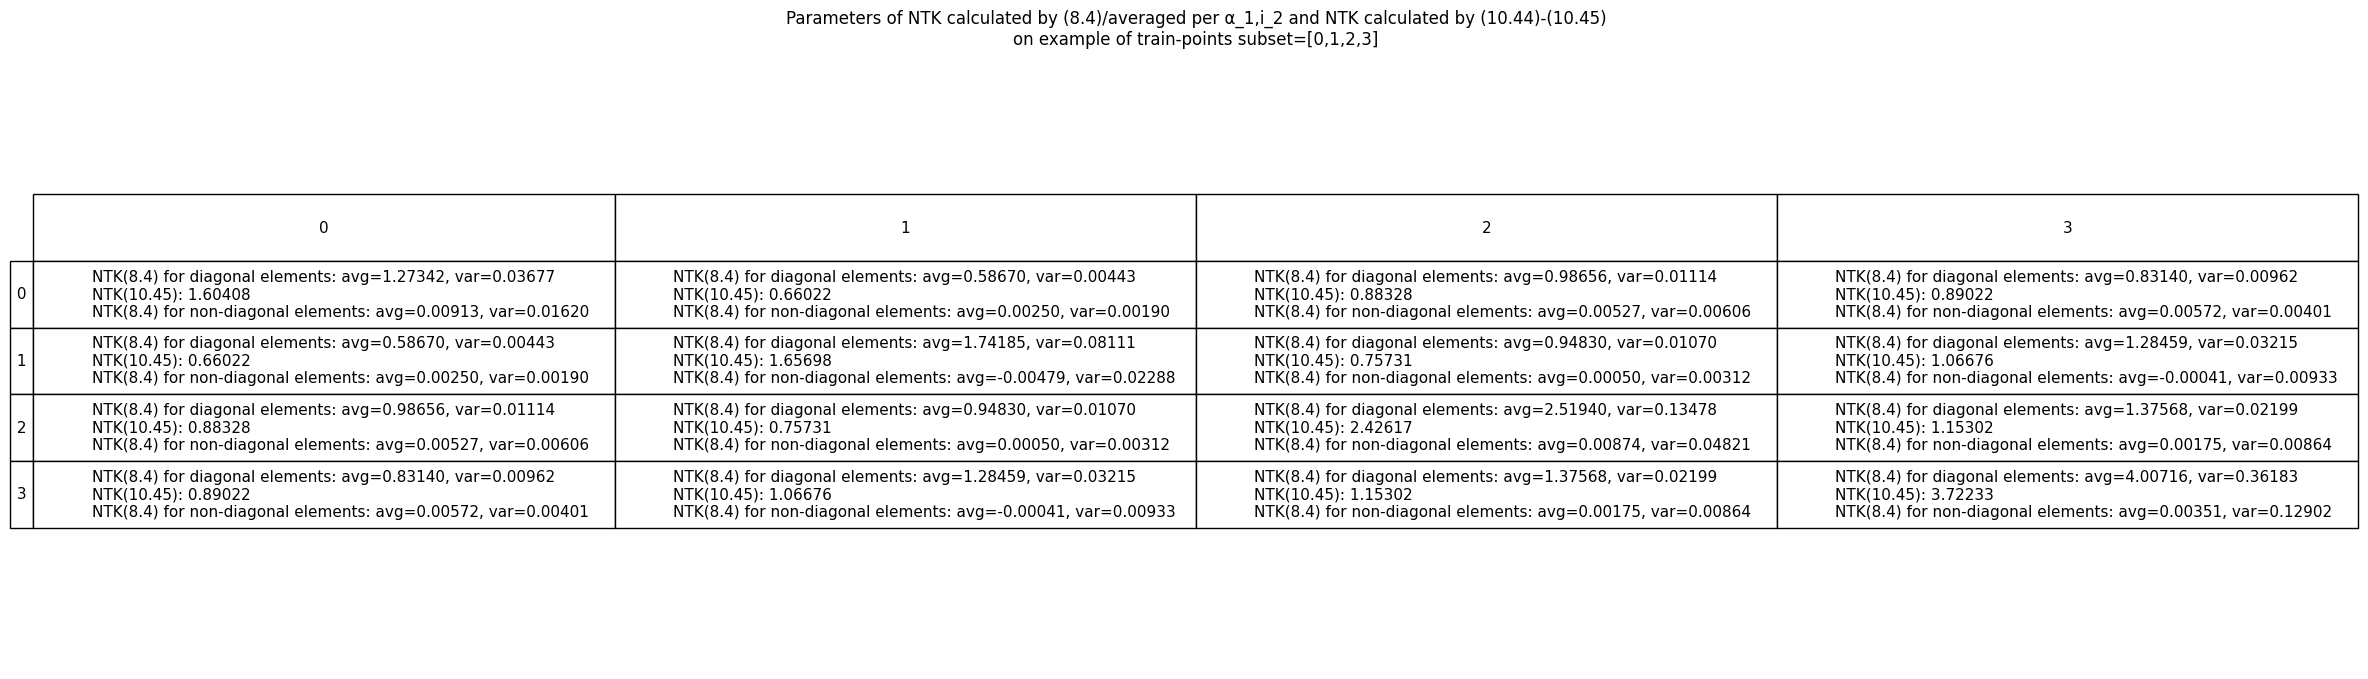

In [37]:
report = np.zeros((4,4), dtype='U256')
for row, col in itr.product(range(4), range(4)):
    report[row, col] = "NTK(8.4) for diagonal elements: avg="+rf(HL_avg[row, col])\
        +", var="+rf(HL_var[row, col])+"\nNTK(10.45): "+rf(thetaL[row, col])+"\n"\
        +"NTK(8.4) for non-diagonal elements: avg="+rf(HLNDG_avg[row, col])+", var="+rf(HLNDG_var[row, col])

fig, ax = plt.subplots(figsize=(10, 8))

# hide axes
#fig.patch.set_visible(False)
ax.axis('off')
ax.axis('tight')

tab_plot = ax.table(cellText=report, colLabels=['0','1','2','3'], rowLabels=[' 0 ',' 1 ',' 2 ',' 3 '], cellLoc='left', loc='center')
tab_plot.auto_set_font_size(False)
tab_plot.set_fontsize(11)
tab_plot.scale(3, 4)
#fig.tight_layout()
ax.set_title('Parameters of NTK calculated by (8.4)/averaged per α_1,i_2 and NTK calculated by (10.44)-(10.45)\n'\
             +'on example of train-points subset=[0,1,2,3]')
plt.show()


#### NTK dynamic during gradient descent steps

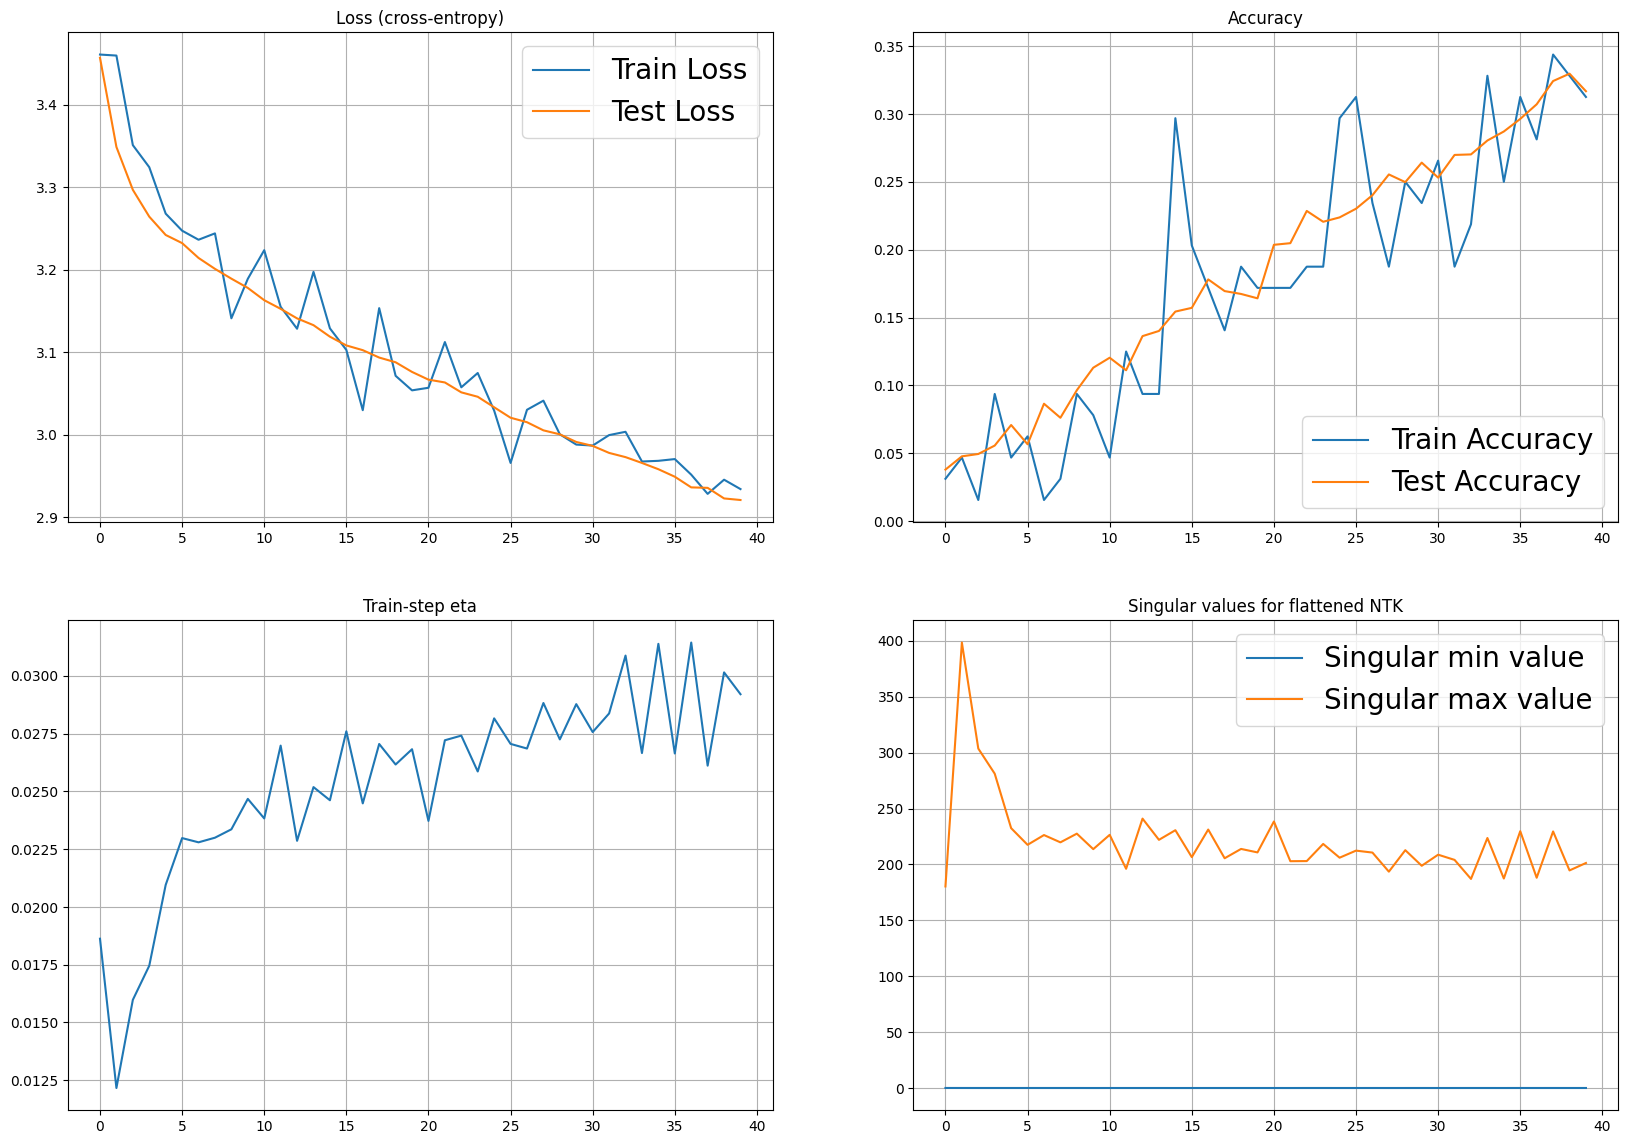

Test accuracy = 0.3167307692307692


In [38]:
HISTORY_PARAMS = collections.defaultdict(list)
GRADIENT_DESCENT_STEPS = 40

etas = [0.0, 0.0]
stepCalc0 = StepCalculatorEtaNtk(meta, ntk_recalc_steps_period = 0)
epoch_count = 0

iter_number = 0
for train_batch in train_dataloader:
    if iter_number >= GRADIENT_DESCENT_STEPS:
        break
    iter_number += 1        
    images, labels_raw = train_batch
    labels = torch.tensor([x-1 for x in labels_raw])
    images = images.to(DEVICE)
    labels = labels.to(DEVICE)

    batch_size = images.shape[0]
    xx = images.view(batch_size, -1)
    testNet.grad_zero
    logits = testNet.forward_(xx)
    etas, HL = stepCalc0.step(testNet, labels, logits, etas)
    HISTORY_PARAMS['train_eta'].append(etas[0])
    HL2d = flatten2d(HL)
    sungulars = svdvals(HL2d)
    HISTORY_PARAMS['ntk_sungular_min'].append(np.min(sungulars))
    HISTORY_PARAMS['ntk_sungular_max'].append(np.max(sungulars))

    # calculate current average loss and accuracy
    zz_logits = np.transpose(logits.detach().numpy())
    prediction = logits.argmax(dim=-1).detach()
    loss = loss_crossentropy(zz_logits, labels)
    HISTORY_PARAMS['train_loss'].append(loss)
    HISTORY_PARAMS['train_accuracy'].append(calculate_accuracy(prediction,labels))

    # testing loop
    test_loss_meter, test_accuracy_meter = AverageMeter(), AverageMeter()
    for test_batch in test_dataloader:
        images, labels_raw = test_batch
        labels = torch.tensor([x-1 for x in labels_raw])
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)        
        with torch.no_grad():
            # do everything like we did in training loop
            batch_size = images.shape[0]
            xx = images.view(batch_size, -1)
            logits = testNet.forward_(xx)

            zz_logits = np.transpose(logits.detach().numpy())
            prediction = logits.argmax(dim=-1).detach()
            loss = loss_crossentropy(zz_logits, labels)
            test_loss_meter.update(loss)
            test_accuracy_meter.update(
                calculate_accuracy(
                    prediction,
                    labels
                )
            )

    # save average test accuracy loss and accuracy
    HISTORY_PARAMS['test_loss'].append(test_loss_meter.avg)
    HISTORY_PARAMS['test_accuracy'].append(test_accuracy_meter.avg)
    
    visualise(HISTORY_PARAMS)
    print("Test accuracy = {}".format(test_accuracy_meter.avg))

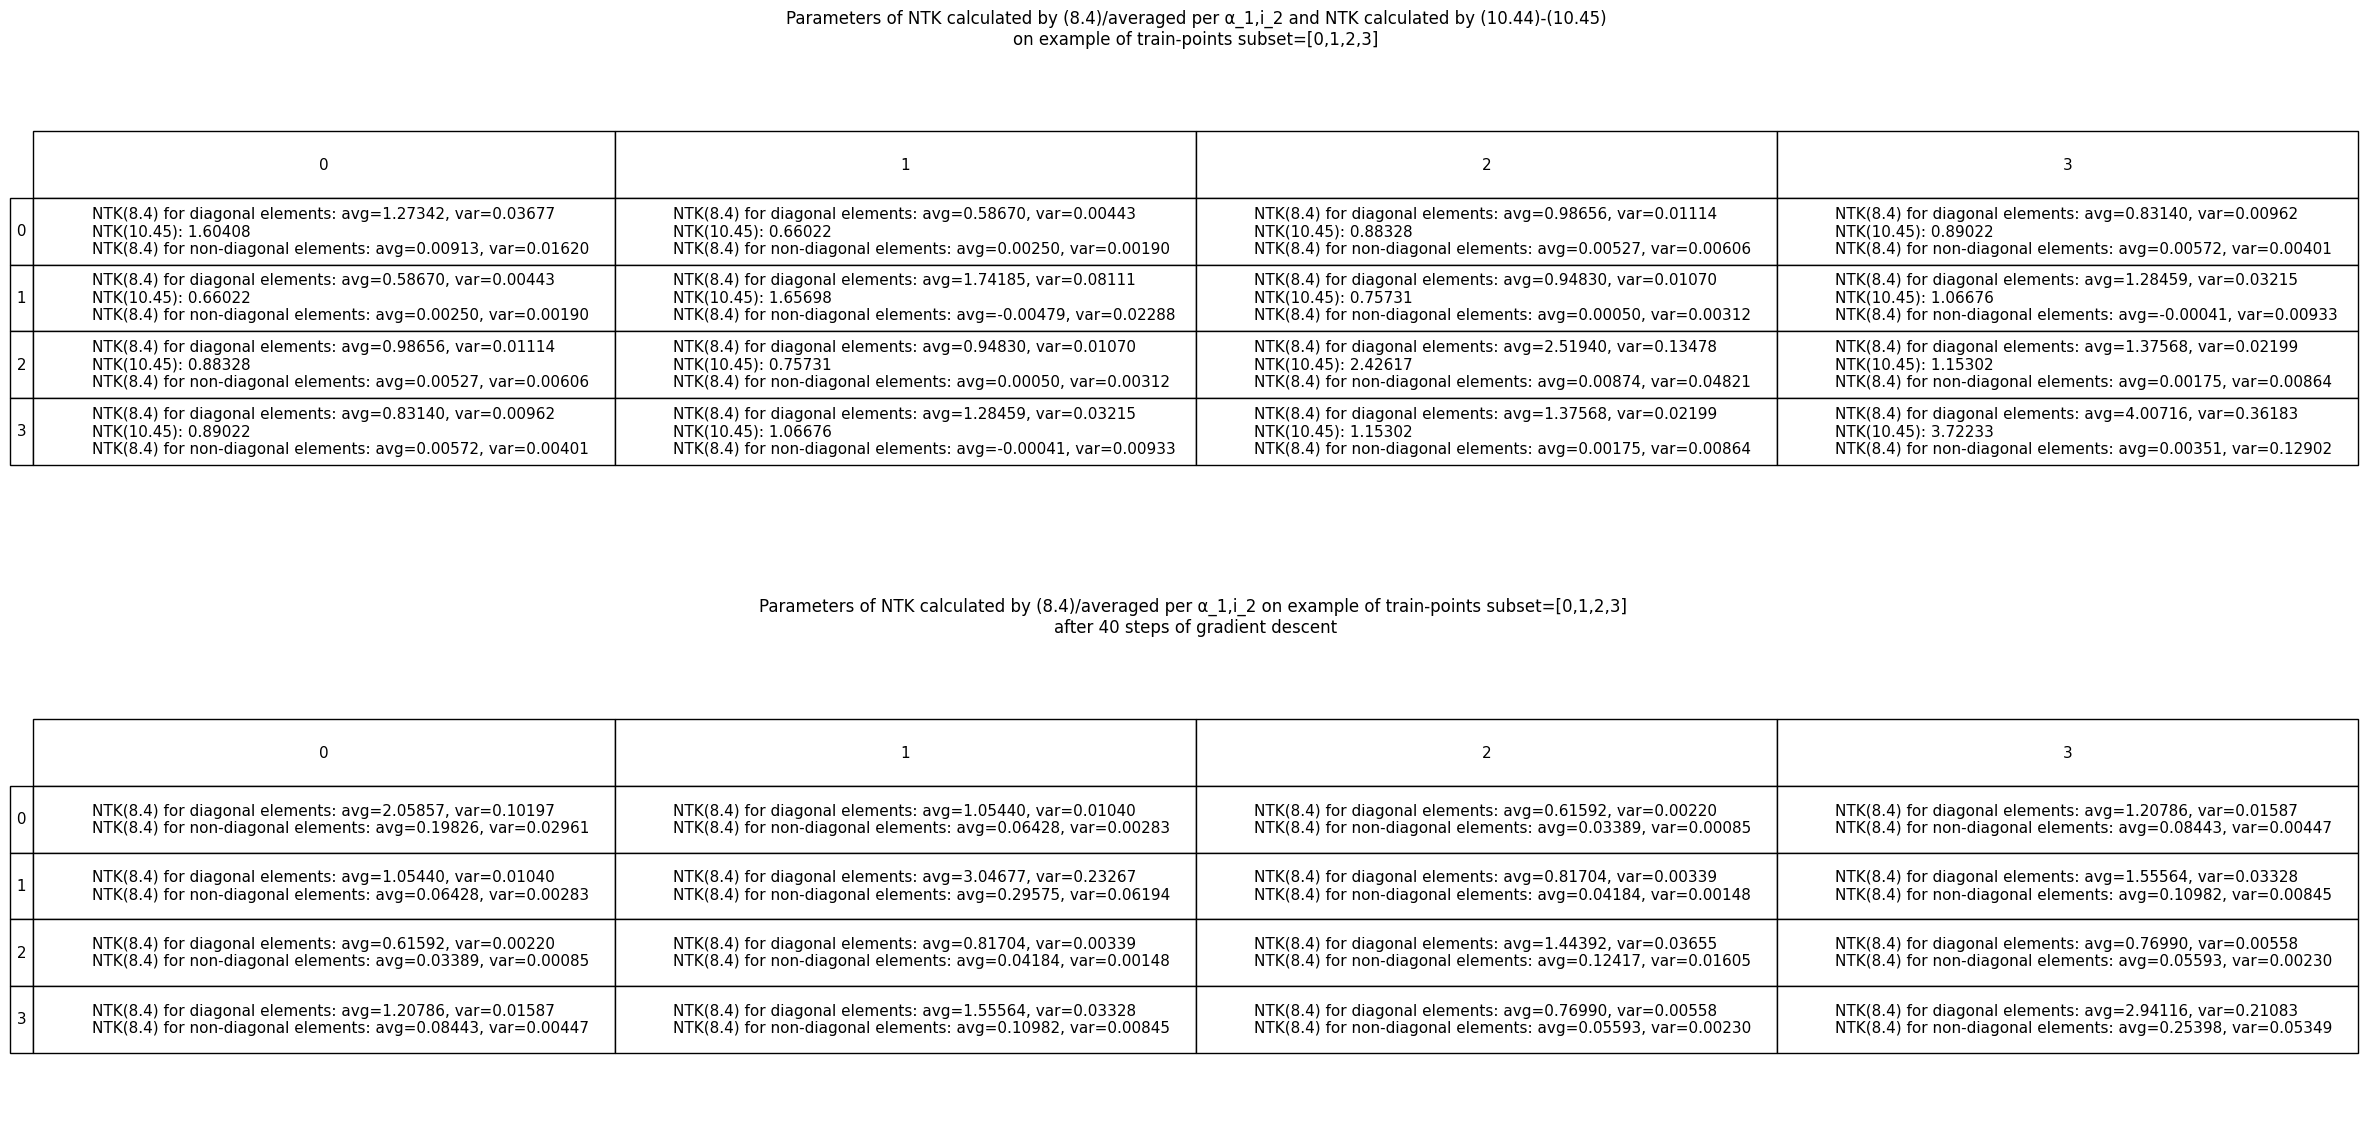

In [39]:
HL_avg, HL_var, HLNDG_avg, HLNDG_var = calc_averages(HL, meta)

report2 = np.zeros((4,4), dtype='U256')
for row, col in itr.product(range(4), range(4)):
    report2[row, col] =\
        "NTK(8.4) for diagonal elements: avg="+rf(HL_avg[row, col])+", var="+rf(HL_var[row, col])+"\n"\
        +"NTK(8.4) for non-diagonal elements: avg="+rf(HLNDG_avg[row, col])+", var="+rf(HLNDG_var[row, col])

fig, axes = plt.subplots(2, 1, figsize=(10, 14))

axes[0].axis('off')
axes[0].axis('tight')
tab_plot = axes[0].table(cellText=report, colLabels=['0','1','2','3'], rowLabels=[' 0 ',' 1 ',' 2 ',' 3 ']\
                         , cellLoc='left', loc='center')
tab_plot.auto_set_font_size(False)
tab_plot.set_fontsize(11)
tab_plot.scale(3, 4)
#fig.tight_layout()
axes[0].set_title('Parameters of NTK calculated by (8.4)/averaged per α_1,i_2 and NTK calculated by (10.44)-(10.45)\n'\
             +'on example of train-points subset=[0,1,2,3]')

axes[1].axis('off')
axes[1].axis('tight')
tab_plot = axes[1].table(cellText=report2, colLabels=['0','1','2','3'], rowLabels=[' 0 ',' 1 ',' 2 ',' 3 ']\
                         , cellLoc='left', loc='center')
tab_plot.auto_set_font_size(False)
tab_plot.set_fontsize(11)
tab_plot.scale(3, 4)
#fig.tight_layout()
axes[1].set_title('Parameters of NTK calculated by (8.4)/averaged per α_1,i_2 '\
             +'on example of train-points subset=[0,1,2,3] \nafter {} steps of gradient descent'\
                .format(GRADIENT_DESCENT_STEPS))
plt.show()